In [1]:
from gala.units import UnitSystem
from astropy import units as u
usys = UnitSystem(u.kpc, u.Myr, u.Msun, u.radian)
import jax.numpy as jnp
from astropy.coordinates import SkyCoord, Galactocentric


import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np

from streamsculptor import potential
from streamsculptor import JaxCoords as jc

import interpax

from astropy.constants import G
import diffrax

from streamsculptor import JaxCoords as jc
import tqdm

import matplotlib as mpl
from jax.scipy.stats import gaussian_kde

## Some plotting things (not necessary)
import scienceplots
plt.style.use('science')
mpl.rcParams['text.usetex'] = False ## We do not have LaTex on the HPC...

In [2]:
import pandas as pd

In [3]:
from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import Galactocentric

import gala.coordinates as gc
from gala.coordinates import reflex_correct

In [4]:
from astropy.table import Table
### load in data from Starkman+2024 (you will need to change this directory to your own file location!)
table = Table.read('members_jet_v0.csv', format='csv')
ra_rad, dec_rad = jnp.deg2rad(table['ra']), jnp.deg2rad(table['dec'])

In [5]:
def icrs_to_gd1(ra_rad, dec_rad):
    """
    define a *differentiable* coordinate transfrom from ra and dec --> gd1 phi1, phi2
    Using the rotation matrix from Koposov+2010
    ra_rad: icrs ra [radians]
    dec_red: icrs dec [radians]
    """
    R = np.array(
        [
        [-0.69796993, 0.6112632, -0.37308885],
        [-0.62616799, -0.26812463, 0.7321358],
        [0.34749337, 0.74462505, 0.56989637],
    ])

    icrs_vec = jnp.vstack([jnp.cos(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(dec_rad)]).T

    stream_frame_vec = jnp.einsum('ij,kj->ki',R,icrs_vec)
    
    phi1 = jnp.arctan2(stream_frame_vec[:,1],stream_frame_vec[:,0])*180/jnp.pi
    phi2 = jnp.arcsin(stream_frame_vec[:,2])*180/jnp.pi

    
    return phi1, phi2

phi1, phi2 = icrs_to_gd1(ra_rad, dec_rad)

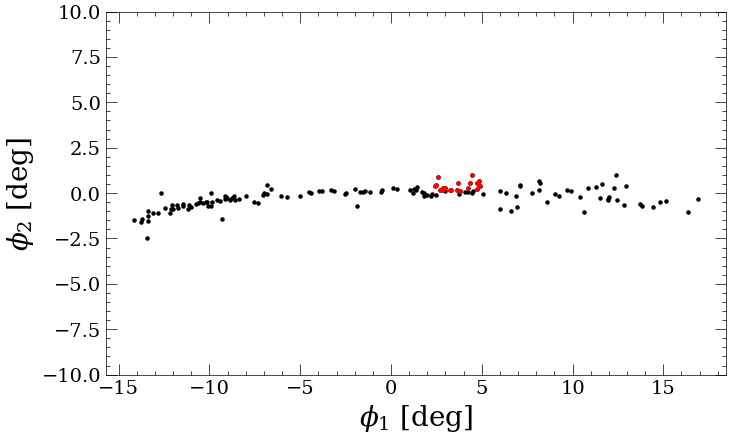

In [6]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(phi1, phi2,s=5,color='k')

## Select some spur stars that we will upweight in the likelihood function
phi2_select_thresh = 0.1
spur_bool = (phi2 > phi2_select_thresh) & (phi1 < 5) &(phi1>2)
ax.scatter(phi1[spur_bool], phi2[spur_bool],s=5,color='r')


ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

In [7]:
prog_data = pd.read_csv("members_jet_v0.csv", delimiter = ',', header = 0)

In [8]:
#select_phi1 = np.abs(prog_data['phi1']) < 2
select_phi1 = (prog_data['phi1'] < -2.8) & ( prog_data['phi1'] > -3.4)

In [9]:
# phi1med = np.median(prog_data.loc[select_phi1, 'phi1'])
phi1med = -3
phi2med = np.median(prog_data.loc[select_phi1, 'phi2'])
ramed = np.median(prog_data.loc[select_phi1, 'ra'])
decmed = np.median(prog_data.loc[select_phi1, 'dec'])
pmramed = np.median(prog_data.loc[select_phi1, 'pmra'])
pmdecmed = np.median(prog_data.loc[select_phi1, 'pmdec'])
rvmed = np.median(prog_data.loc[select_phi1, 'vel_calib'])
dmodmed = np.median(prog_data.loc[select_phi1, 'dist_mod'])
dist_kpc = (10 ** (dmodmed/5 +1))*1e-3
dist_kpc_data = (10 ** ((prog_data['dist_mod'])/5 +1))*1e-3

In [10]:
jet_c = coord.SkyCoord(ra=ramed*u.degree, dec=decmed*u.degree, distance=dist_kpc*u.kpc, pm_ra_cosdec=pmramed*u.mas/u.yr,
                        pm_dec=pmdecmed*u.mas/u.yr,
                        radial_velocity=rvmed*u.km/u.s)

In [11]:
rep = jet_c.transform_to(coord.Galactocentric)

In [70]:
print(rep)

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in kpc
    (-17.94554266, -28.82334508, 8.28403302)
 (v_x, v_y, v_z) in km / s
    (6.41515665, -82.20483774, -122.52882062)>


In [71]:
vx = rep.v_x.to(u.kpc/u.Myr)
vy = rep.v_y.to(u.kpc/u.Myr)
vz = rep.v_z.to(u.kpc/u.Myr)

In [72]:
print(rep.x)

-17.945542662902554 kpc


In [73]:
print(rep.x.value)

-17.945542662902554


In [74]:
prog_wtoday = jnp.array([rep.x.value,rep.y.value,rep.z.value,vx.value,vy.value,vz.value]) #changing position 

In [75]:
print(prog_wtoday)

[-1.79455427e+01 -2.88233451e+01  8.28403302e+00  6.56085875e-03
 -8.40718876e-02 -1.25311715e-01]


In [76]:
## Use Gala's MW potential
pot = potential.GalaMilkyWayPotential(units=usys)
## Define the age of the stream [Myr]
t_age = 7000.0
## Past time at which it dissolved [Myr]
t_dissolve = -2500.0
## Get initial conditions
IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,ts=jnp.array([-t_age])).ys[0]
## Define stripping times. ts[-1] is always the final integration time for gen_stream simulations
ts = jnp.hstack([jnp.linspace(-t_age,t_dissolve,4_000), jnp.array([0.0])])
## Generate unperturbed stream [l: lead, t: trail]
l ,t = pot.gen_stream_vmapped(prog_w0=IC,ts=ts,seed_num=532,Msat=1e4,atol=1e-6,rtol=1e-6,solver=diffrax.Dopri5())
stream = jnp.vstack([l,t])


In [77]:
stream.shape

(8000, 6)

In [78]:
@jax.jit
def get_rv_from_stream(stream):
    """
    Differentiable helper function that takes us from simulated stream --> phi1, phi2
    """
    pm_ra_cosdec, pm_dec, rv = jax.vmap(jc.simvel_to_ICRS)(stream[:,:3], stream[:,3:])
    #phi1_model, phi2_model = icrs_to_gd1(ra_s*jnp.pi/180, dec_s*jnp.pi/180)  #add in coordinate transformations to phi1 phi2 pms
    return pm_ra_cosdec, pm_dec, rv

pm_ra_cosdec, pm_dec, rv = get_rv_from_stream(stream) # in kpc/Myr -- convert to km/s
print(rv)
rv = rv*u.kpc/u.Myr
rv = rv.to(u.km/u.s)
print(rv)
print(prog_data['vel_calib'])

[0.26000726 0.2549386  0.25019236 ... 0.27595387 0.27666519 0.27732506]
[254.23307624 249.27697877 244.636141   ... 269.82554321 270.52107331
 271.16628538] km / s
0      255.773169
1      239.083718
2      266.644871
3      267.552953
4      276.580058
          ...    
147    248.208278
148    234.721396
149    279.043281
150    273.741117
151    252.839541
Name: vel_calib, Length: 152, dtype: float64


In [79]:
@jax.jit
def get_phi12_from_stream(stream):
    """
    Differentiable helper function that takes us from simulated stream --> phi1, phi2
    """
    ra_s, dec_s, dist_ = jax.vmap(jc.simcart_to_icrs)(stream[:,:3])
    phi1_model, phi2_model = icrs_to_gd1(ra_s*jnp.pi/180, dec_s*jnp.pi/180)
    return phi1_model, phi2_model

phi1_model, phi2_model = get_phi12_from_stream(stream[:,:3])

    

In [80]:
print(len(phi1_model))
print(len(rv))

8000
8000


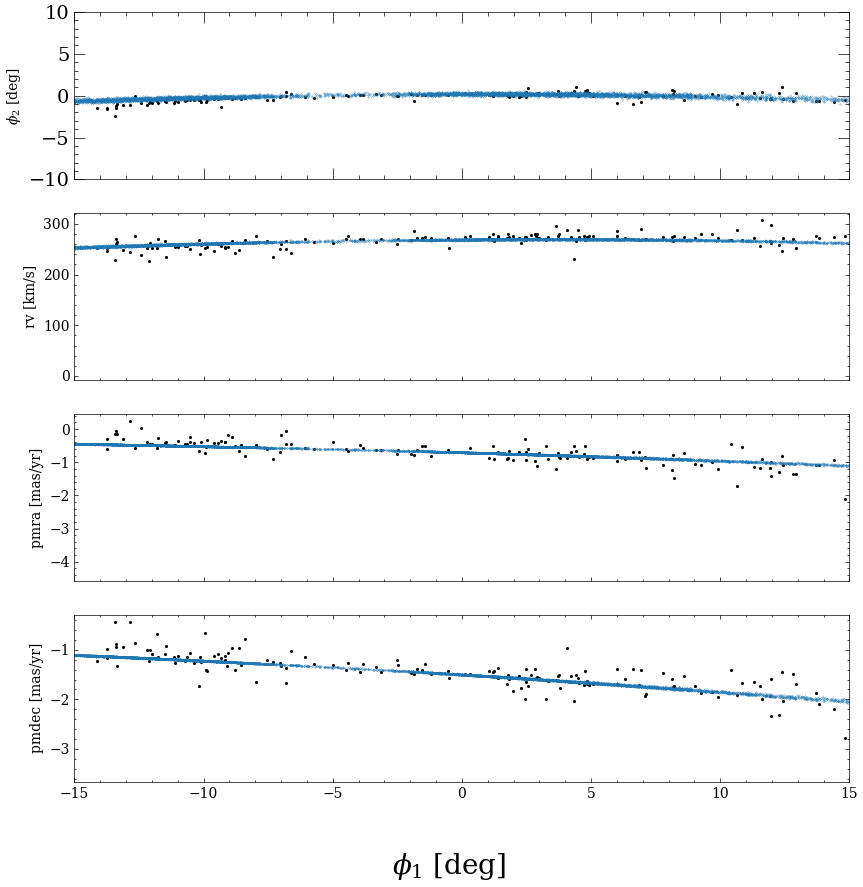

In [81]:
fig, ax = plt.subplots(4,1, sharex = True)
fig.set_size_inches(10,10)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[0].scatter(phi1, phi2,s=1.5,color='k')
ax[0].scatter(phi1_model, phi2_model,s=.05,color='tab:blue')
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-10,10)
ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
ax[1].scatter(phi1, prog_data['vel_calib'],s=1.5,color='k')
ax[1].scatter(phi1_model, rv,s=.05,color='tab:blue')
ax[1].set_ylabel('rv [km/s]', fontsize=10)
ax[2].scatter(phi1, prog_data['pmra'],s=1.5,color='k')
ax[2].scatter(phi1_model, pm_ra_cosdec,s=.05,color='tab:blue')
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
ax[3].scatter(phi1, prog_data['pmdec'],s=1.5,color='k')
ax[3].scatter(phi1_model, pm_dec,s=.05,color='tab:blue')
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
ax[-1].set_xlim(-15,15)
fig.savefig('streamsc_jet_sim_vs_obs.pdf')
#ax.set_aspect('equal')

In [65]:
phi1_min = 5
phi1_max = 16.
@jax.jit
def log_like_provided_data_model(phi1_data=None, phi2_data=None, phi1_model=None, phi2_model=None,phi1_min=phi1_min, phi1_max=phi1_max, phi2_min=-10.,phi2_max=10.0,bw=0.15,
                                spur_ids=None):
    inp_data = jnp.vstack([phi1_data, phi2_data])
    inp_model = jnp.vstack([phi1_model, phi2_model])
    ## Weights for the kde: start with uniform
    weights = jnp.ones_like(phi1_model)
    ## Check where the model is outside of the domain (Omega)
    pred = (phi1_model < phi1_min) | (phi1_model > phi1_max) | (phi2_model < phi2_min) | (phi2_model > phi2_max)
    ## wherever the model is outsize of the domain, set the weights to zero.
    ## This way the model has no support outside of the domain
    weights = jnp.where( pred, 0.0, weights)
    ## N0 = N_model here
    N0 = jnp.sum(weights)
    weights = weights/weights.sum()
    ## Fit the kde
    kde = gaussian_kde(inp_model,bw_method=bw, weights=weights)
    ## N = N_data
    N = len(phi1_data)
    logpdf = kde.logpdf(inp_data)
    ## Next we define the w_i's, or the importance weights below
    ## Generate id list of importance weights
    importance_weights_idx = jnp.arange(len(phi1_data))
    ## Check if importance weights are in spur_ids. If they are, assign a value of 1.5. Otherwise, 1.
    importance_weights = jnp.where(jnp.isin(importance_weights_idx,spur_ids),1.5,1.) 
    
    return  -N0 + N*jnp.log(N0) + jnp.sum(logpdf*importance_weights)

## Bool for where data is in the domain (Omega)
data_in_bool = (phi1 > phi1_min) & (phi1< phi1_max)

spur_in_bool = spur_bool[data_in_bool]
spur_ids = jnp.where(spur_in_bool==True)[0]

In [26]:
# test the log-likelihood
test_like = log_like_provided_data_model(phi1_model=phi1_model, phi2_model=phi2_model, phi1_data=phi1[data_in_bool], phi2_data=phi2[data_in_bool],
                                       spur_ids=spur_ids)
print(test_like)

-2863.065507610675


In [27]:
def plot_kde(phi1_data=None, phi2_data=None, phi1_model=None, phi2_model=None,phi1_min=phi1_min, phi1_max=phi1_max, phi2_min=-10.,phi2_max=10.0,bw=0.1):
    inp_data = jnp.vstack([phi1_data, phi2_data])
    inp_model = jnp.vstack([phi1_model, phi2_model])
    weights = jnp.ones_like(phi1_model)
    pred = (phi1_model < phi1_min) | (phi1_model > phi1_max) | (phi2_model < phi2_min) | (phi2_model > phi2_max)
    weights = jnp.where( pred, 0.0, weights)
    kde = gaussian_kde(inp_model,bw_method=bw, weights=weights)
    xlin = jnp.linspace(-100,40,150)
    ylin = jnp.linspace(-10,10,151)
    X,Y = jnp.meshgrid(xlin,ylin)
    inp_eval = jnp.vstack([X.flatten(),Y.flatten()])
    return X, Y, kde.pdf(inp_eval).reshape(X.shape)

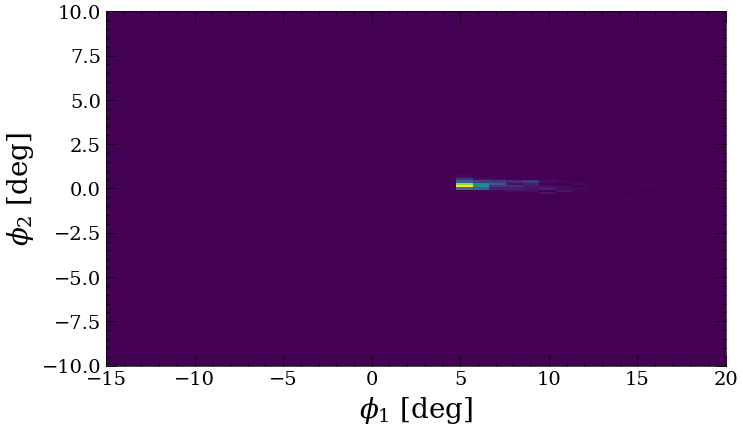

In [28]:
out_plot = plot_kde(phi1_model=phi1_model, phi2_model=phi2_model, phi1_data=phi1[data_in_bool], phi2_data=phi2[data_in_bool])

####
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(phi1_model, phi2_model,s=.05,color='tab:blue')

ax.pcolormesh(out_plot[0],out_plot[1],out_plot[2])

#ax.scatter(phi1, phi2,s=1.5,color='k')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-15,20)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

In [29]:
## import the impact generator, for generator parameters for subhalo impacts
from streamsculptor.GenerateImpactParams import ImpactGenerator
ImpactGen = ImpactGenerator(pot=pot, tobs=0.0, stream=stream, stream_phi1=phi1_model, phi1_bounds=[phi1_min,phi1_max],
                           tImpactBounds=[-2500,0.0],phi1window=.8)

In [30]:
## Import the stream generator (vmap, because we're using a GPU)
from streamsculptor import gen_stream_vmapped_with_pert

In [31]:
## Now we're going to import a differentiable spline function.
## We will fit this spline to the unperturbed stream in phase-space, such that we can
## evaluate x(phi1), y(phi1), ... etc.
import interpax

def get_cart_spline(phi1, stream):
    spl_funcs = []
    for i in range(6):
        spl_funcs.append(interpax.Interpolator1D(x=phi1,f=stream[:,i],method='cubic2'))
    return spl_funcs
print(stream)
def eval_splines(phi1_eval, splines):
    output = jnp.zeros(6)
    for i in range(6):
        output = output.at[i].set(splines[i](phi1_eval))
    return output


args_phi1 = jnp.argsort(phi1_model)
splines = get_cart_spline(phi1_model[args_phi1], stream[args_phi1,:])
eval_mean = lambda phi1_eval:eval_splines(phi1_eval,splines)

print(eval_mean)

eval_mean = jax.jit(eval_mean)

print(eval_mean)

## Example: get the mean phase-space coord at phi1 of :
print('example 1: ' +str(eval_mean(5.0)))

## Example: get the gradient of the mean phase-space coord wrspct to phi1, at phi1 of 
print('example 2: ' +str(jax.jacfwd(eval_mean)(5.0)))

[[-1.77914918e+01 -2.91545564e+01  7.38136889e+00  9.73914305e-03
  -7.83975613e-02 -1.20430986e-01]
 [-1.77581784e+01 -2.92485213e+01  7.28196449e+00  1.01958387e-02
  -7.75003553e-02 -1.20544602e-01]
 [-1.74692106e+01 -3.00619075e+01  5.40921884e+00  1.98548445e-02
  -6.15858433e-02 -1.24739934e-01]
 ...
 [-1.80739687e+01 -2.74923484e+01  1.03167568e+01 -5.34635073e-03
  -1.02522218e-01 -1.11880283e-01]
 [-1.83864686e+01 -2.73661105e+01  1.12479140e+01 -8.38338395e-03
  -1.06284283e-01 -1.09104149e-01]
 [-1.82109071e+01 -2.74378328e+01  1.06323345e+01 -6.41653004e-03
  -1.03776612e-01 -1.10935882e-01]]
<function <lambda> at 0x3301855a0>
<PjitFunction of <function <lambda> at 0x3301855a0>>
example 1: [-1.76592445e+01 -2.45785123e+01  1.12759387e+01 -2.03807651e-02
 -1.25573685e-01 -1.06217197e-01]
example 2: [ 2.48655270e+02  1.88638419e+03 -8.92913162e+02 -8.40253888e+00
 -1.14168036e+01  8.49940756e-01]


In [8]:
## Some functions to generate the perturbed stream.
## There are more clean ways to do this using ImpactGen,
## but the default function to take phi1 --> mean phase-space coord is not differentiable.
## This will be changed in the future.
@jax.jit
def get_subhalo_params_cart(sampled_params):
    
    stream_mean = eval_mean(sampled_params['phi1_0'])  
    XV_Impact, __ = ImpactGen._get_subhalo_ImpactParamsCartesian(tobs=0.0,particle_mean=stream_mean, tImpact=-10**sampled_params['log10_tImpact'],
                                                bImpact=10**sampled_params['log10_bImpact'], vImpact=sampled_params['vImpact'],
                                                phi=sampled_params['phi'], beta=sampled_params['beta'],
                                                gamma=sampled_params['gamma'])
    
    
    return XV_Impact

@jax.jit
def gen_perturbed_stream(total_param_dict):
    """
    subhalo_params is a dictionary containing Cartesian information for the subhalo impact
    """
    XV_Impact = get_subhalo_params_cart(total_param_dict)
    
    pot_SH = potential.SubhaloLinePotential(m=jnp.array([10**total_param_dict['log10_m']]), a=jnp.array([10**total_param_dict['log10_a']]),
                                            subhalo_x0=jnp.array([XV_Impact[:3]]),
                                            subhalo_v=jnp.array([XV_Impact[3:]]),
                                            subhalo_t0=jnp.array([-10**total_param_dict['log10_tImpact']]),
                                            t_window=jnp.array([100.0]),
                                            units=usys)
    
    pot_lst = [pot, pot_SH]
    pot_total = potential.Potential_Combine(pot_lst,units=usys)
    
    IC = pot_total.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,ts=jnp.array([-t_age]),max_steps=20_000).ys[0]
    l ,t = gen_stream_vmapped_with_pert(pot_base=pot, pot_pert=pot_SH, prog_w0=IC, ts=ts, seed_num=532, Msat=1e4, max_steps=20_000,
                                        atol=1e-6,rtol=1e-6, solver=diffrax.Dopri5(), dtmin=0.05)
    stream = jnp.vstack([l,t])

    return stream




In [62]:
dir(test_dict)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [65]:
## Test dictionary with parameter inputs
test_dict = dict(phi1_0=-7, phi2_0=0.5,log10_tImpact=jnp.log10(800.0), log10_bImpact=-3., vImpact=.15, phi=.2,beta=.1,gamma=0.01,log10_m=7.2,log10_a=jnp.log10(.05))
## output the cartesian parameters of the subhalo at impact:
get_subhalo_params_cart(test_dict)

Array([ -8.07389637, -12.49331755,   6.09612991,   0.02144876,
        -0.07234052,  -0.12964104], dtype=float64)

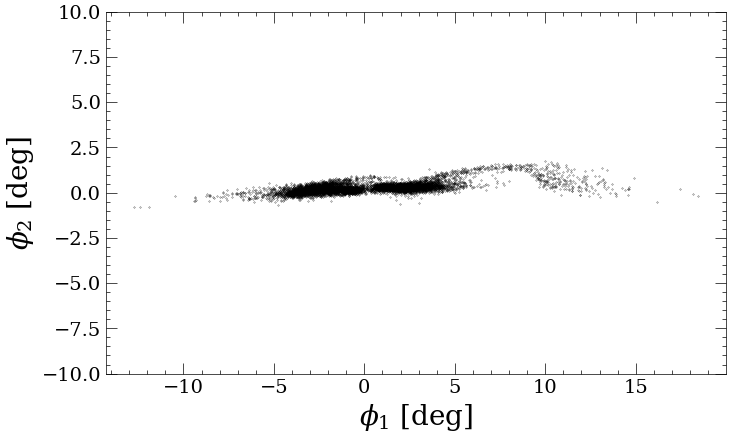

In [66]:
## Example perturbed stream
test_stream = gen_perturbed_stream(test_dict)
p1_test, p2_test = get_phi12_from_stream(test_stream[:,:3])

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(p1_test, p2_test,s=0.05,color='k')
    
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

In [43]:
@jax.jit
def ln_likelihood(param_dict):
    """
    ln_likelihood function that takes only a parameter dictionary as input
    """
    stream_out = gen_perturbed_stream(param_dict)
    phi1_model, phi2_model = get_phi12_from_stream(stream_out[:,:3])
    log_like = log_like_provided_data_model(phi1_model=phi1_model, phi2_model=phi2_model, phi1_data=phi1[data_in_bool], 
                                            phi2_data=phi2[data_in_bool],spur_ids=spur_ids,bw=.15)
    return log_like

In [44]:
## We will create a batched (or mapped) likelihood evaluation function.
## This function takes in a param dict, where each key has an array of values 
## corresponding to each simulation. 
## We will run the simulations using jax vectorization. 
## I.e., we can run ~600 simulations in around 10 seconds using vmap's internal
## optimizations and parallelization on gpu
map_dict = {}
for key in test_dict:
    map_dict[key] = 0

print(map_dict)
mapped_ln_like = jax.jit(jax.vmap(ln_likelihood,in_axes=(map_dict,)))

{'phi1_0': 0, 'log10_tImpact': 0, 'log10_bImpact': 0, 'vImpact': 0, 'phi': 0, 'beta': 0, 'gamma': 0, 'log10_m': 0, 'log10_a': 0}


In [45]:
def sample_prior(seed=None, n_samp=None):
    key = jax.random.PRNGKey(seed)
    
    log10_m = jax.random.uniform(key, (n_samp,), minval=6.0, maxval=7.0)
    key, subkey = jax.random.split(key)
    log10_a = jax.random.uniform(subkey, (n_samp,), minval=jnp.log10(0.01), maxval=jnp.log10(0.2))
    key, subkey = jax.random.split(key)
    phi1_0 = jax.random.uniform(subkey, (n_samp,), minval=-15, maxval=17)
    key, subkey = jax.random.split(key)
    log10_tImpact = jax.random.uniform(subkey, (n_samp,), minval=1, maxval=jnp.log10(2_000))
    key, subkey = jax.random.split(key)
    log10_bImpact = jax.random.uniform(subkey, (n_samp,), minval=-5, maxval=jnp.log10(0.5))
    key, subkey = jax.random.split(key)
    vImpact = jax.random.uniform(subkey, (n_samp,), minval=-0.4, maxval=0.4)
    key, subkey = jax.random.split(key)
    phi = jax.random.uniform(subkey, (n_samp,), minval=0.0, maxval=jnp.pi)
    key, subkey = jax.random.split(key)
    beta = jax.random.uniform(subkey, (n_samp,), minval=0.0, maxval=jnp.pi/2)
    key, subkey = jax.random.split(key)
    gamma = jax.random.uniform(subkey, (n_samp,), minval=0.0, maxval=jnp.pi/2)
    return {
        'log10_m': log10_m,
        'log10_a': log10_a,
        'phi1_0': phi1_0,
        'log10_tImpact': log10_tImpact,
        'log10_bImpact': log10_bImpact,
        'vImpact': vImpact,
        'phi': phi,
        'beta': beta,
        'gamma': gamma,
   
    }


In [46]:
## Sample batches of simulations
def batch_simulation(seed, n_batch, n_total_batch):
    key = jax.random.PRNGKey(seed)
    all_samples = []
    all_likelihoods = []
    count = 0 
    for _ in tqdm.tqdm(range(n_total_batch)):
        
        priors = sample_prior(seed + count, n_batch)
        count+=1
        
        # Evaluate log-likelihoods for all samples
        log_likes = mapped_ln_like(priors)
        
        for i in range(n_batch):
            sample = {k: v[i] for k, v in priors.items()}
            all_samples.append(sample)
            all_likelihoods.append(log_likes[i])
    
    return all_samples, all_likelihoods

In [47]:
### I have  cell runs on a A100 GPU

seed = 8942
# Number of simulations to run in one iteration
n_batch = 1
# How many iterations we are running total
n_total_batch = 1
print('total number of simulations being run: ' + str(n_batch*n_total_batch))
samples, likelihoods = batch_simulation(seed, n_batch, n_total_batch)


total number of simulations being run: 1


100%|█████████████████████████████████████████████| 1/1 [00:06<00:00,  6.17s/it]


In [48]:
## transform to array and visualize best fit below

ll = jnp.asarray(likelihoods)


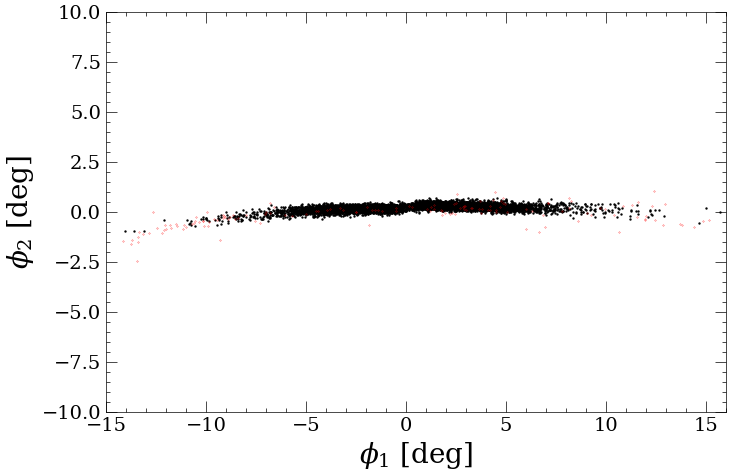

In [49]:
best_fit = samples[jnp.argmax(ll)] 

### Visualize the best fit of the 28000 runs
test_stream = gen_perturbed_stream(best_fit)
p1_test, p2_test = get_phi12_from_stream(test_stream[:,:3])

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(p1_test, p2_test,s=0.5,color='k')
ax.scatter(phi1, phi2,s=0.05,color='r')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-15,16)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

In [50]:
### Gradient of ln-likelihood is simple as
grad_func = jax.jit(jax.jacfwd(ln_likelihood))

def gradient_ascent(params, learning_rates, num_iterations):
    trajectory = []
    loglike = []
    for i in range(num_iterations):
        grads = grad_func(params)
        params = {k: v + learning_rates[k] * grads[k] for k, v in params.items()}
        ll = ln_likelihood(params)
        trajectory.append(params)
        loglike.append(ll)
        if i % 5 == 0:  # Print progress every 10 iterations
            arr = jnp.asarray(loglike)
            print(f"Iteration {i}, max lnlikelihood {str(arr.max())}")
    return params, trajectory, loglike

In [51]:
## Gradient of ln-likelihood at the best fit
## *first compile will take awhile* Subsequent runs are faster.
print(grad_func(best_fit)) 

{'beta': Array(100.56942523, dtype=float64), 'gamma': Array(-62.57211753, dtype=float64), 'log10_a': Array(-0.02397337, dtype=float64), 'log10_bImpact': Array(0.00785894, dtype=float64), 'log10_m': Array(73.04926484, dtype=float64), 'log10_tImpact': Array(5545.3555292, dtype=float64), 'phi': Array(0.00112993, dtype=float64), 'phi1_0': Array(66.95630189, dtype=float64), 'vImpact': Array(700.06249817, dtype=float64)}


In [52]:
lr = 1e-10 
learning_rates = {
    'log10_m': lr,
    'log10_a': lr,
    'phi1_0': lr,
    'log10_tImpact': lr,
    'log10_bImpact': lr,
    'vImpact': lr,
    'phi': lr,
    'beta': lr,
    'gamma': lr
}

In [53]:
nsteps = 20
params_final, traj, loglike_traj = gradient_ascent(best_fit,learning_rates,nsteps) 

Iteration 0, max lnlikelihood -2762.4000672106795
Iteration 5, max lnlikelihood -2760.136003483173
Iteration 10, max lnlikelihood -2759.5125708791784
Iteration 15, max lnlikelihood -2757.1530894525204


In [54]:
loglike_traj = jnp.asarray(loglike_traj)
id_max = jnp.argmax(loglike_traj)
params_MLE = traj[id_max]

In [55]:
print('Original lnL, Improved lnL: ' + str(ln_likelihood(best_fit))+','+str(
                                          ln_likelihood(params_MLE))
                                          )

Original lnL, Improved lnL: -2761.272434879096,-2757.1530894525204


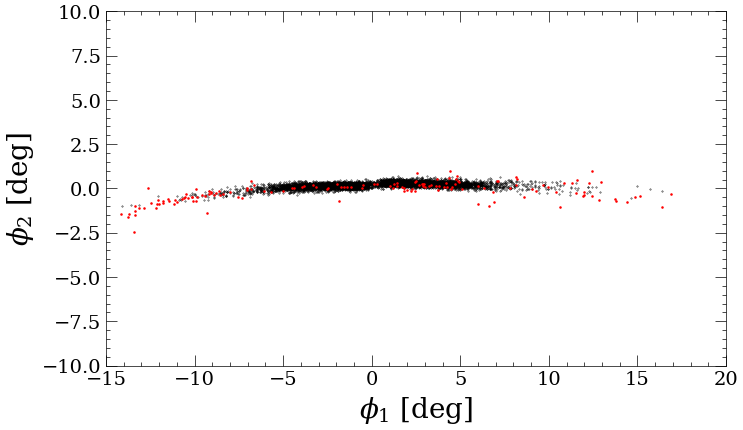

In [56]:
test_stream = gen_perturbed_stream(params_MLE)
p1_test, p2_test = get_phi12_from_stream(test_stream[:,:3])

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(p1_test, p2_test,s=0.1,color='k')
ax.scatter(phi1, phi2,s=0.7,color='r')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-15,20)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

In [57]:
def langevin_sampler(initial_params, num_samples, step_size, rng_key):
    samples = []
    params = initial_params
    for i in tqdm.tqdm(range(num_samples)):
        grads = grad_func(params)
        noise = jax.random.normal(rng_key, shape=jnp.array(list(params.values())).shape)
        params = {k: v + 0.5 * step_size * grads[k] + jnp.sqrt(step_size) * noise[idx] for idx, (k, v) in enumerate(params.items())}
        samples.append(params)
        rng_key, _ = jax.random.split(rng_key)
    return samples

In [ ]:
# Generate a random key
seed = 490
rng_key = jax.random.PRNGKey(seed)
out_samps = langevin_sampler(params_MLE,500,1e-7,rng_key)

  8%|███▏                                      | 38/500 [01:53<23:49,  3.09s/it]

In [69]:
samples_array = np.array([[params[k] for k in params_MLE.keys()] for params in out_samps])
param_range = [1. for _ in range(samples_array.shape[1])]


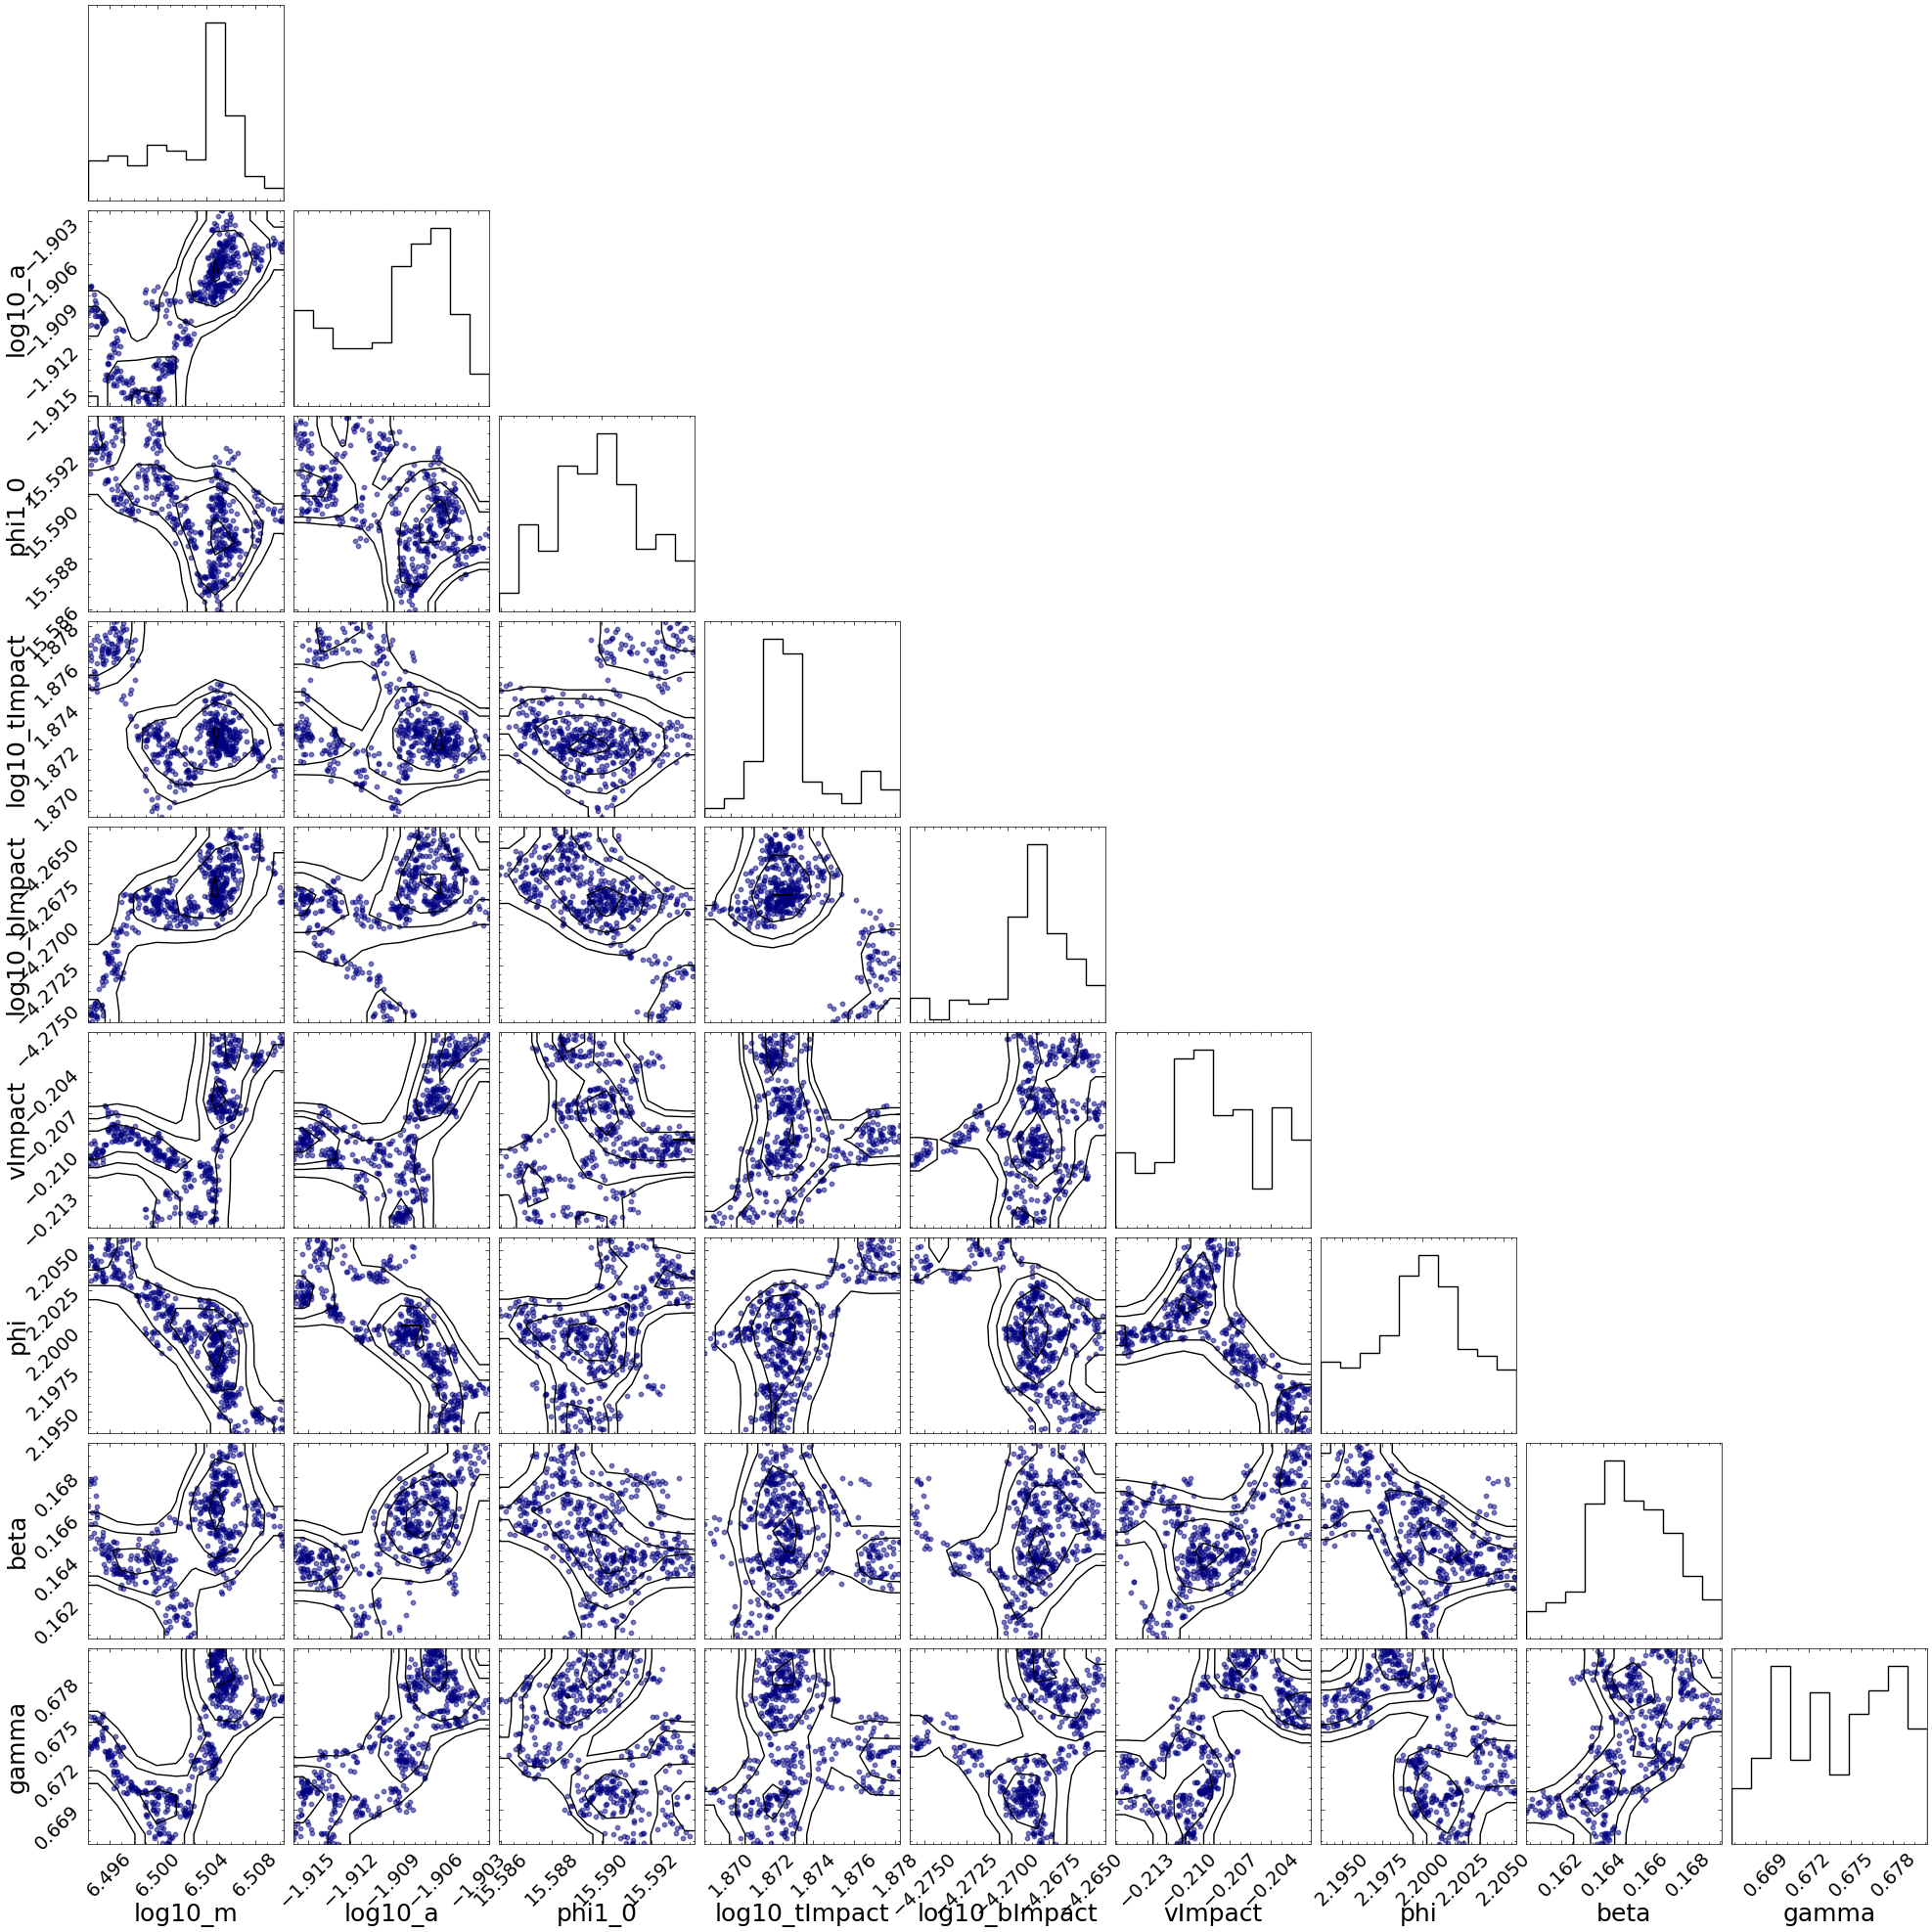

In [70]:
import corner
## Some plotting options
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.labelsize'] = 16  
plt.rcParams['xtick.labelsize'] = 14 
plt.rcParams['ytick.labelsize'] = 14  

figure = corner.corner(samples_array, labels=list(params_MLE.keys()),bins=10,smooth=1.,
                       plot_datapoints=False,plot_contours=True, plot_density=False,
                       range=param_range,label_kwargs={"fontsize": 18} 
                      )
# Overlay the data points on top of the contours
axes = figure.get_axes()
for i in range(len(param_range)):
    for j in range(i):
        ax = axes[i * len(param_range) + j]
        ax.scatter(samples_array[:, j], samples_array[:, i], s=10, color='navy', alpha=0.5,rasterized=True)



In [71]:
### Let's generate a stream from the two main mass modes (low mass SH and higher mass)
low_mass_bool = samples_array[:,0]<6.493
low_mass_sample_inds = jnp.where(low_mass_bool==True)[0]
print(low_mass_sample_inds)
high_mass_sample_inds = jnp.where(low_mass_bool==False)[0]
print(high_mass_sample_inds)

[]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245

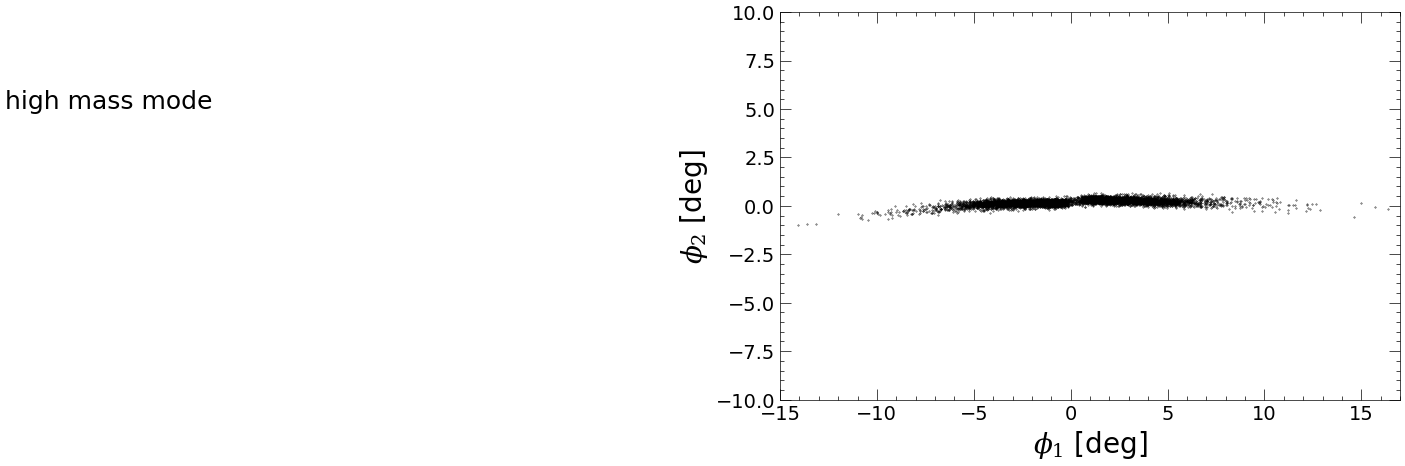

In [74]:
test_stream = gen_perturbed_stream(out_samps[high_mass_sample_inds[28]])
p1_test, p2_test = get_phi12_from_stream(test_stream[:,:3])

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(p1_test, p2_test,s=0.1,color='k')
ax.text(-55,5,'high mass mode',fontsize=18)

#ax.scatter(phi1, phi2,s=0.5,color='r')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-15,17)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')